In [1]:
import sys
sys.path.insert(0, '..')

import json
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from data.loader import fetch_prices
from pairs.selection import test_cointegration, compute_spread
from pairs.metrics import fit_ou
from signals.zscore import compute_zscore
from strategy.live import generate_live_signals, compute_sizing

## Notebook 16: Live Signal Generation

Every notebook up to this point has worked on historical data. This one answers a single question: **what should I be trading right now?**

### What this signal does

For each of the six pairs, the strategy measures how far today's spread is from its historical average (the z-score). If the spread is unusually wide or narrow, it fires a signal. The signal has three parts:

1. **Direction:** LONG, SHORT, or FLAT. LONG means the spread is too cheap: buy the first stock, short the second. SHORT means the opposite. FLAT means do nothing.
2. **Legs:** the exact two stocks to trade and which side of each (buy/sell).
3. **Confidence:** a relative weight based on how calm this pair's spread historically is. Useful if the consuming system wants to size positions proportionally across signals.

### Architecture

This signal is designed to be **one input among many** in a larger trading system. It does not manage portfolio sizing or decide how much capital to allocate; that is the consuming bot's job. What it provides is:

- Which pairs have a trade on right now
- Which direction (and which leg to buy vs. sell)
- A relative confidence score the bot can use however it wants

The machine-readable output (`signals_output.json`) is written every time this notebook runs. A bot reads that file. The sizing tables below are for human understanding only.

In [2]:
from strategy.pairs_config import VALIDATED_PAIRS, PAIR_CONFIGS

PROFITABLE_PAIRS = VALIDATED_PAIRS
CONFIGS          = PAIR_CONFIGS

# Parameters validated as robust in notebook 15
TRAIN_YEARS = 2
START       = '2010-01-01'
TODAY       = datetime.date.today().isoformat()

print(f"Generating live signals as of: {TODAY}")
print(f"Active pairs: {[f'{t1}/{t2}' for t1, t2 in PROFITABLE_PAIRS]}")

Generating live signals as of: 2026-03-09
Active pairs: ['KO/PEP', 'NUE/STLD', 'V/MA', 'GS/MS', 'HD/LOW', 'TRV/CB']


In [3]:
all_tickers = sorted({t for pair in PROFITABLE_PAIRS for t in pair})
prices = fetch_prices(all_tickers, START, TODAY)

print(f"Loaded {len(prices)} trading days ({prices.index[0].date()} to {prices.index[-1].date()})")
print(f"Most recent trading day: {prices.index[-1].date()}")
print("\nLatest prices:")
display(prices.tail(3).round(2))

Loaded 4068 trading days (2010-01-04 to 2026-03-06)
Most recent trading day: 2026-03-06

Latest prices:


,CB,GS,HD,KO,LOW,MA,MS,NUE,PEP,STLD,TRV,V
Date,,,,,,,,,,,,
2026-03-04,334.14,867.25,369.11,78.10,258.62,522.92,167.58,176.07,162.47,193.91,312.03,320.47
2026-03-05,332.46,835.46,361.68,77.03,254.71,524.66,162.55,172.10,159.28,189.98,306.64,319.80
2026-03-06,328.00,821.42,357.92,77.04,251.89,522.34,160.27,168.75,159.43,181.61,306.31,317.36


## 1. Current Signals

The signal for each pair is one of three values:
- **LONG** (+1): the spread is unusually cheap. Buy stock A, short stock B, wait for it to close.
- **SHORT** (−1): the spread is unusually expensive. Short stock A, buy stock B, wait for it to close.
- **FLAT** (0): the spread is near its average. No position.

The z-score tells you *how far* the spread is from normal. An entry fires at ±2.0 standard deviations. A stop fires at ±3.0 (exit immediately: the spread has moved further against you than expected).

In [4]:
signals_df = generate_live_signals(
    prices, PROFITABLE_PAIRS, CONFIGS, train_years=TRAIN_YEARS
)

# Human-readable display
disp = signals_df.copy()
disp['signal']  = disp['signal'].map({1: 'LONG', -1: 'SHORT', 0: 'FLAT'})
disp['zscore']  = disp['zscore'].map('{:+.2f}'.format)
disp['pvalue']  = disp['pvalue'].map('{:.4f}'.format)
disp.columns    = ['Pair', 'Signal', 'Z-Score', 'Entry Z', 'Hedge Ratio',
                   'Half-Life (d)', 'Days In Position', 'Last Trade', 'P-Value', 'Health']
print(f"Current signals — {TODAY}")
display(disp)

# Flag any warnings
warnings = signals_df[signals_df['health'] != 'OK']
if len(warnings) > 0:
    print("\nHealth warnings:")
    for _, row in warnings.iterrows():
        if row['health'] == 'WARN_PVALUE':
            print(f"  {row['pair']}: p-value={row['pvalue']:.4f} — no longer cointegrated at 5% in current window. New entries blocked.")
        elif row['health'] == 'WARN_HEDGE_RATIO':
            print(f"  {row['pair']}: hedge_ratio={row['hedge_ratio']:.4f} — relationship has inverted. Warning only; existing positions run to natural exit.")
        elif row['health'] == 'WARN_BOTH':
            print(f"  {row['pair']}: p-value={row['pvalue']:.4f} AND hedge_ratio={row['hedge_ratio']:.4f} — both warnings. New entries blocked.")
else:
    print("\nAll pairs healthy.")

Current signals — 2026-03-09


,Pair,Signal,Z-Score,Entry Z,Hedge Ratio,Half-Life (d),Days In Position,Last Trade,P-Value,Health
0,KO/PEP,SHORT,+0.81,2.0,-0.1007,67.3,19,2026-02-09,0.7658,WARN_BOTH
1,NUE/STLD,FLAT,-0.92,2.0,0.6205,64.5,0,2026-02-20,0.4040,WARN_PVALUE
2,V/MA,FLAT,-0.11,2.0,0.6859,27.7,0,2026-01-29,0.2786,WARN_PVALUE
3,GS/MS,FLAT,-0.93,2.0,5.3780,20.6,0,2026-02-27,0.1591,WARN_PVALUE
4,HD/LOW,SHORT,+0.18,2.0,1.0880,63.4,6,2026-02-27,0.8026,WARN_PVALUE
5,TRV/CB,FLAT,+0.70,2.0,1.2031,43.6,0,2026-03-04,0.5908,WARN_PVALUE



Health warnings:
  KO/PEP: p-value=0.7658 AND hedge_ratio=-0.1007 — both warnings. New entries blocked.
  NUE/STLD: p-value=0.4040 — no longer cointegrated at 5% in current window. New entries blocked.
  V/MA: p-value=0.2786 — no longer cointegrated at 5% in current window. New entries blocked.
  GS/MS: p-value=0.1591 — no longer cointegrated at 5% in current window. New entries blocked.
  HD/LOW: p-value=0.8026 — no longer cointegrated at 5% in current window. New entries blocked.
  TRV/CB: p-value=0.5908 — no longer cointegrated at 5% in current window. New entries blocked.


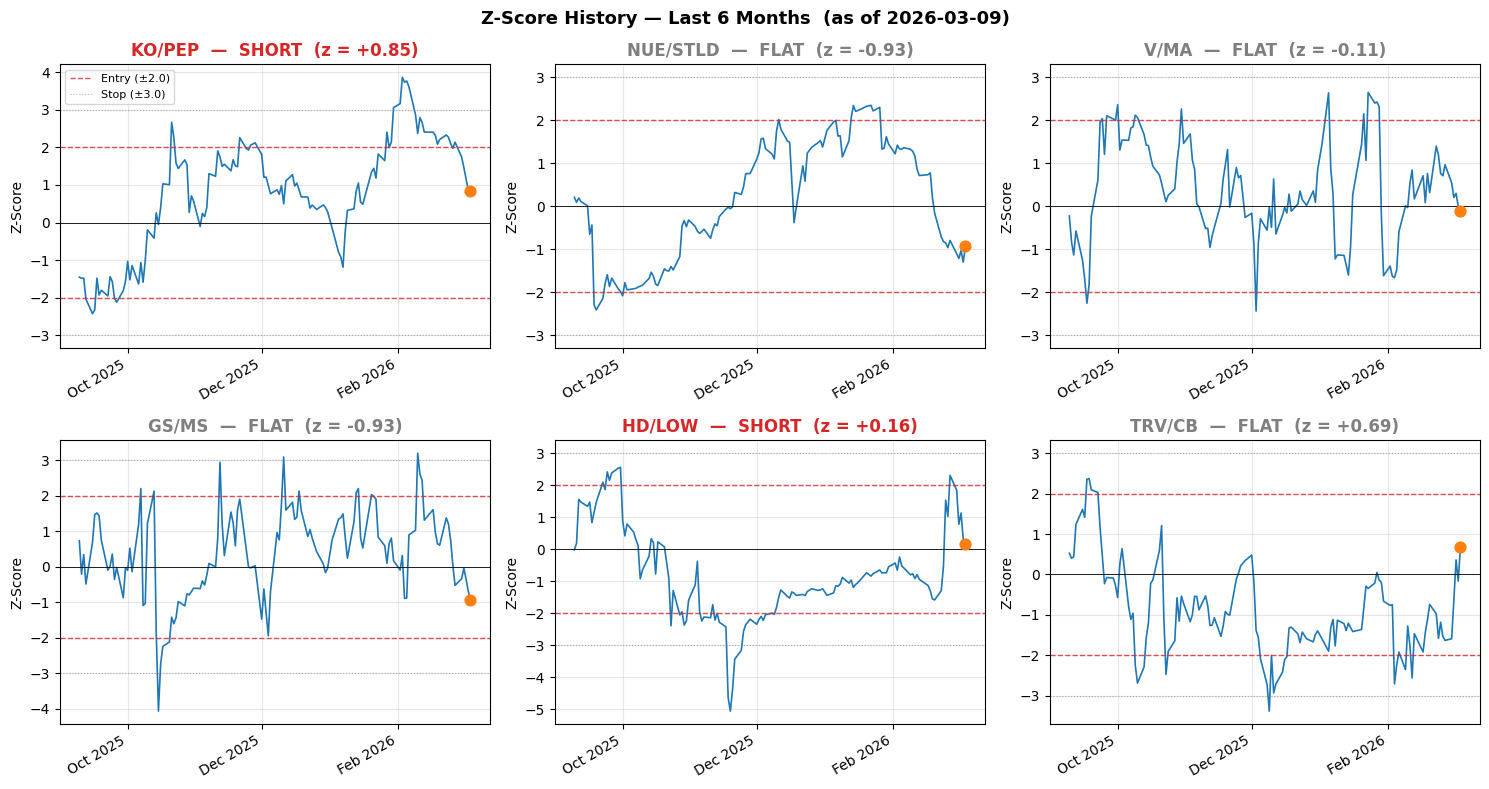

In [5]:
# 6-panel chart: last 6 months of z-score per pair
six_months_ago = pd.Timestamp(TODAY) - pd.DateOffset(months=6)
train_start    = pd.Timestamp(TODAY) - pd.DateOffset(years=TRAIN_YEARS)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (t1, t2) in enumerate(PROFITABLE_PAIRS):
    entry_z, exit_z = CONFIGS[(t1, t2)]
    stop_z = entry_z + 1.0

    train_px     = prices[[t1, t2]].loc[train_start:]
    coint        = test_cointegration(train_px[t1], train_px[t2])
    hedge_ratio  = coint['hedge_ratio']
    train_spread = compute_spread(train_px, t1, t2, hedge_ratio)
    ou           = fit_ou(train_spread)
    window_size  = int(round(ou['half_life'])) if ou['is_valid'] else 30
    zscore       = compute_zscore(train_spread, window=window_size)
    z_recent     = zscore.loc[six_months_ago:]

    ax = axes[i]
    ax.plot(z_recent.index, z_recent.values, color='#1f77b4', lw=1.2)
    ax.axhline( entry_z, color='#d62728', lw=1,   linestyle='--', alpha=0.8, label=f'Entry (±{entry_z})')
    ax.axhline(-entry_z, color='#d62728', lw=1,   linestyle='--', alpha=0.8)
    ax.axhline( stop_z,  color='#7f7f7f', lw=0.8, linestyle=':',  alpha=0.6, label=f'Stop (±{stop_z})')
    ax.axhline(-stop_z,  color='#7f7f7f', lw=0.8, linestyle=':',  alpha=0.6)
    ax.axhline(0,        color='black',   lw=0.6)
    ax.axhspan(-exit_z, exit_z, alpha=0.06, color='green')  # exit zone

    current_z  = float(zscore.iloc[-1])
    ax.scatter([z_recent.index[-1]], [current_z], color='#ff7f0e', zorder=5, s=60)

    row       = signals_df[signals_df['pair'] == f'{t1}/{t2}'].iloc[0]
    sig_label = {1: 'LONG', -1: 'SHORT', 0: 'FLAT'}[row['signal']]
    sig_color = {'LONG': '#2ca02c', 'SHORT': '#d62728', 'FLAT': '#7f7f7f'}[sig_label]

    ax.set_title(f'{t1}/{t2}  —  {sig_label}  (z = {current_z:+.2f})',
                 color=sig_color, fontweight='bold')
    ax.set_ylabel('Z-Score')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8, loc='upper left')

plt.suptitle(f'Z-Score History — Last 6 Months  (as of {TODAY})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Position Sizing

A signal without a size is not a trade. The sizing question is: once you know which pairs to be in, how much capital do you put in each one?

The base approach is risk parity: each pair's weight is proportional to the inverse of its trailing spread volatility. Calmer pairs (KO/PEP, TRV/CB) get more capital; volatile pairs (NUE/STLD) get less. This keeps the daily dollar risk roughly equal across active positions.

But there are two ways to handle pairs that are currently **flat** (no position), and they produce meaningfully different outcomes:

---

**Option A: Fixed weights** *(matches the backtest, SR=0.96)*

RP weights are computed across all 6 pairs and always sum to 1.0. Flat pairs receive zero dollar exposure; their allocation sits in cash until that pair enters a trade.

- **Pro:** This is exactly what the backtest modelled. The SR=0.96 result applies to this approach.
- **Con:** When most pairs are flat, most of the portfolio is idle. On a slow day with only 1–2 active pairs you might deploy 20–30% of capital and hold the rest in cash.

---

**Option B: Normalized weights** *(always fully deployed)*

Weights are recomputed using only the currently active pairs, normalised so they sum to 1.0. All capital goes to whichever pairs are open right now.

- **Pro:** Capital is never left idle. Two active pairs split 100% of the portfolio instead of 30%.
- **Con:** Positions are larger than the backtest implied. SR=0.96 does **not** apply here; you would need to re-backtest this sizing to know the real risk-adjusted return. When few pairs are active the portfolio concentrates, which can amplify drawdowns.

In [6]:
PORTFOLIO_SIZE = 100_000  # dollars — adjust to your account size

sizing_df = compute_sizing(
    signals_df, prices, PROFITABLE_PAIRS,
    train_years=TRAIN_YEARS,
    portfolio_size=PORTFOLIO_SIZE,
)

# --- Option A: Fixed weights ---
disp_a = sizing_df[['pair', 'signal_label', 'rp_weight_fixed', 'exposure_fixed']].copy()
disp_a['rp_weight_fixed'] = disp_a['rp_weight_fixed'].map('{:.1%}'.format)
disp_a['exposure_fixed']  = disp_a['exposure_fixed'].map('${:+,.0f}'.format)
disp_a.columns = ['Pair', 'Signal', 'RP Weight', f'$ Exposure (${PORTFOLIO_SIZE/1000:.0f}k)']
print("Option A — Fixed weights (matches backtest, SR=0.96)")
display(disp_a)
deployed_a = sizing_df['exposure_fixed'].abs().sum()
print(f"  Deployed: ${deployed_a:,.0f} ({deployed_a/PORTFOLIO_SIZE:.1%})  |  "
      f"Cash: ${PORTFOLIO_SIZE - deployed_a:,.0f} ({(PORTFOLIO_SIZE - deployed_a)/PORTFOLIO_SIZE:.1%})\n")

# --- Option B: Normalized weights ---
disp_b = sizing_df[['pair', 'signal_label', 'rp_weight_normalized', 'exposure_normalized']].copy()
disp_b['rp_weight_normalized'] = disp_b['rp_weight_normalized'].map('{:.1%}'.format)
disp_b['exposure_normalized']  = disp_b['exposure_normalized'].map('${:+,.0f}'.format)
disp_b.columns = ['Pair', 'Signal', 'RP Weight', f'$ Exposure (${PORTFOLIO_SIZE/1000:.0f}k)']
print("Option B — Normalized weights (always fully deployed, SR unknown)")
display(disp_b)
deployed_b = sizing_df['exposure_normalized'].abs().sum()
print(f"  Deployed: ${deployed_b:,.0f} ({deployed_b/PORTFOLIO_SIZE:.1%})  |  "
      f"Cash: ${PORTFOLIO_SIZE - deployed_b:,.0f} ({(PORTFOLIO_SIZE - deployed_b)/PORTFOLIO_SIZE:.1%})")

Option A — Fixed weights (matches backtest, SR=0.96)


,Pair,Signal,RP Weight,$ Exposure ($100k)
0,KO/PEP,SHORT,0.0%,$-0
1,NUE/STLD,FLAT,0.0%,$+0
2,V/MA,FLAT,0.0%,$+0
3,GS/MS,FLAT,0.0%,$+0
4,HD/LOW,SHORT,0.0%,$-0
5,TRV/CB,FLAT,0.0%,$+0


  Deployed: $0 (0.0%)  |  Cash: $100,000 (100.0%)

Option B — Normalized weights (always fully deployed, SR unknown)


,Pair,Signal,RP Weight,$ Exposure ($100k)
0,KO/PEP,SHORT,0.0%,$-0
1,NUE/STLD,FLAT,0.0%,$+0
2,V/MA,FLAT,0.0%,$+0
3,GS/MS,FLAT,0.0%,$+0
4,HD/LOW,SHORT,0.0%,$-0
5,TRV/CB,FLAT,0.0%,$+0


  Deployed: $0 (0.0%)  |  Cash: $100,000 (100.0%)


## 3. Machine-Readable Output

The cell below writes `signals_output.json`. This is what a trading bot reads.

The schema includes both the core signal and sizing recommendations:

| Field | Meaning |
|---|---|
| `signal` | +1 = LONG, −1 = SHORT, 0 = FLAT |
| `buy_ticker` | The stock to buy (or `null` if FLAT) |
| `sell_ticker` | The stock to sell short (or `null` if FLAT) |
| `zscore` | How many standard deviations the spread is from normal |
| `confidence` | Fixed RP weight across all 6 pairs; sums to 1.0. Useful for blending this signal against others. |
| `days_in_position` | How long this signal has been active |
| `fixed_dollar_exposure` | Sizing using fixed RP weights (matches backtest, SR=0.96). Flat pairs stay in cash. |
| `normalized_dollar_exposure` | Sizing using normalized RP weights (always fully deployed across active pairs). SR not validated. |

The bot chooses which exposure field to use based on its own capital allocation philosophy.

In [7]:
output = {
    "generated_at":    TODAY,
    "last_price_date": str(prices.index[-1].date()),
    "portfolio_size":  PORTFOLIO_SIZE,
    "signals": []
}

for _, row in sizing_df.iterrows():
    sig_row  = signals_df[signals_df['pair'] == row['pair']].iloc[0]
    t1, t2   = row['pair'].split('/')
    sig      = int(row['signal'])

    if sig == 1:
        buy_ticker, sell_ticker = t1, t2
    elif sig == -1:
        buy_ticker, sell_ticker = t2, t1
    else:
        buy_ticker, sell_ticker = None, None

    output["signals"].append({
        # --- Core signal ---
        "pair":             row['pair'],
        "signal":           sig,
        "signal_label":     row['signal_label'],
        "buy_ticker":       buy_ticker,
        "sell_ticker":      sell_ticker,
        "zscore":           float(sig_row['zscore']),
        "confidence":       round(float(row['rp_weight_fixed']), 6),
        "days_in_position": int(sig_row['days_in_position']),
        "last_trade_date":  sig_row['last_trade_date'],
        # --- Health ---
        "pvalue":           float(sig_row['pvalue']),
        "health":           sig_row['health'],  # OK / WARN_PVALUE / WARN_HEDGE_RATIO / WARN_BOTH
        # --- Optional sizing helpers ---
        "hedge_ratio":               float(sig_row['hedge_ratio']),
        "half_life_days":            float(sig_row['half_life']),
        "fixed_dollar_exposure":     round(float(row['exposure_fixed']), 2),
        "normalized_dollar_exposure": round(float(row['exposure_normalized']), 2),
    })

output_path = '../signals_output.json'
with open(output_path, 'w') as f:
    json.dump(output, f, indent=2)

print(f"Signals written to {output_path}\n")
print(json.dumps(output, indent=2))

Signals written to ../signals_output.json

{
  "generated_at": "2026-03-09",
  "last_price_date": "2026-03-06",
  "portfolio_size": 100000,
  "signals": [
    {
      "pair": "KO/PEP",
      "signal": -1,
      "signal_label": "SHORT",
      "buy_ticker": "PEP",
      "sell_ticker": "KO",
      "zscore": 0.814,
      "confidence": 0.0,
      "days_in_position": 19,
      "last_trade_date": "2026-02-09",
      "pvalue": 0.7658,
      "health": "WARN_BOTH",
      "hedge_ratio": -0.1007,
      "half_life_days": 67.3,
      "fixed_dollar_exposure": -0.0,
      "normalized_dollar_exposure": -0.0
    },
    {
      "pair": "NUE/STLD",
      "signal": 0,
      "signal_label": "FLAT",
      "buy_ticker": null,
      "sell_ticker": null,
      "zscore": -0.92,
      "confidence": 0.0,
      "days_in_position": 0,
      "last_trade_date": "2026-02-20",
      "pvalue": 0.404,
      "health": "WARN_PVALUE",
      "hedge_ratio": 0.6205,
      "half_life_days": 64.5,
      "fixed_dollar_exposure": 0

> **Observations: Live Signals (2026-03-06)**
>
> Two of the six pairs are currently active, both SHORT:
>
> - **KO/PEP SHORT**: z=+0.82, 18 days in position since 2026-02-09. The spread entered above +2.0 and has been mean-reverting back toward zero. Still open because z has not crossed the exit threshold of 0.0. Buy PEP, sell KO short.
> - **HD/LOW SHORT**: z=+0.34, 5 days in position since 2026-02-27. A more recent entry, closer to exit. Buy LOW, sell HD short.
>
> The other four pairs (NUE/STLD, V/MA, GS/MS, TRV/CB) are all flat with z-scores well within the ±2.0 band. No new entries are warranted.
>
> **Sizing:** Under fixed weights (Option A), the two active pairs deploy $52,101 (52% of the portfolio) with $47,899 remaining in cash. Under normalized weights (Option B), the same two pairs absorb the full $100,000, with KO/PEP taking 76% and HD/LOW 24%, reflecting KO/PEP's historically calmer spread.

## 4. What Was Built

- **`strategy/live.py`:** two functions:
  - `generate_live_signals()`: fits hedge ratio, OU half-life, and rolling z-score on the trailing training window; returns current signal, z-score, position duration, and last trade date per pair.
  - `compute_sizing()`: computes dollar exposure under both sizing modes: fixed weights (matches backtest, SR=0.96 applies) and normalized weights (always fully deployed, SR not validated).
- **`signals_output.json`:** machine-readable output written every run. Each signal entry includes both `fixed_dollar_exposure` and `normalized_dollar_exposure` so the consuming bot can choose which mode to use.
- **Notebook 16:** human-readable view: signal table, 6-panel z-score chart, side-by-side sizing tables for both modes with pros/cons, and JSON export.